In [1]:
print("hello")

hello


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file csv
df = pd.read_csv('/data/dataset.csv')

# Hiển thị thông tin tổng quan của dataframe
print("--- Cấu trúc dữ liệu ---")
display(df.info())

print("\n--- 5 dòng đầu tiên ---")
display(df.head())

print("\n--- Thống kê mô tả ---")
display(df.describe(include='all'))

FileNotFoundError: [Errno 2] No such file or directory: '/data/dataset.csv'

/tmp/ipykernel_570/1255760132.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dependents', ax=ax4, order=['0', '1', '2', '3+'], palette='viridis')


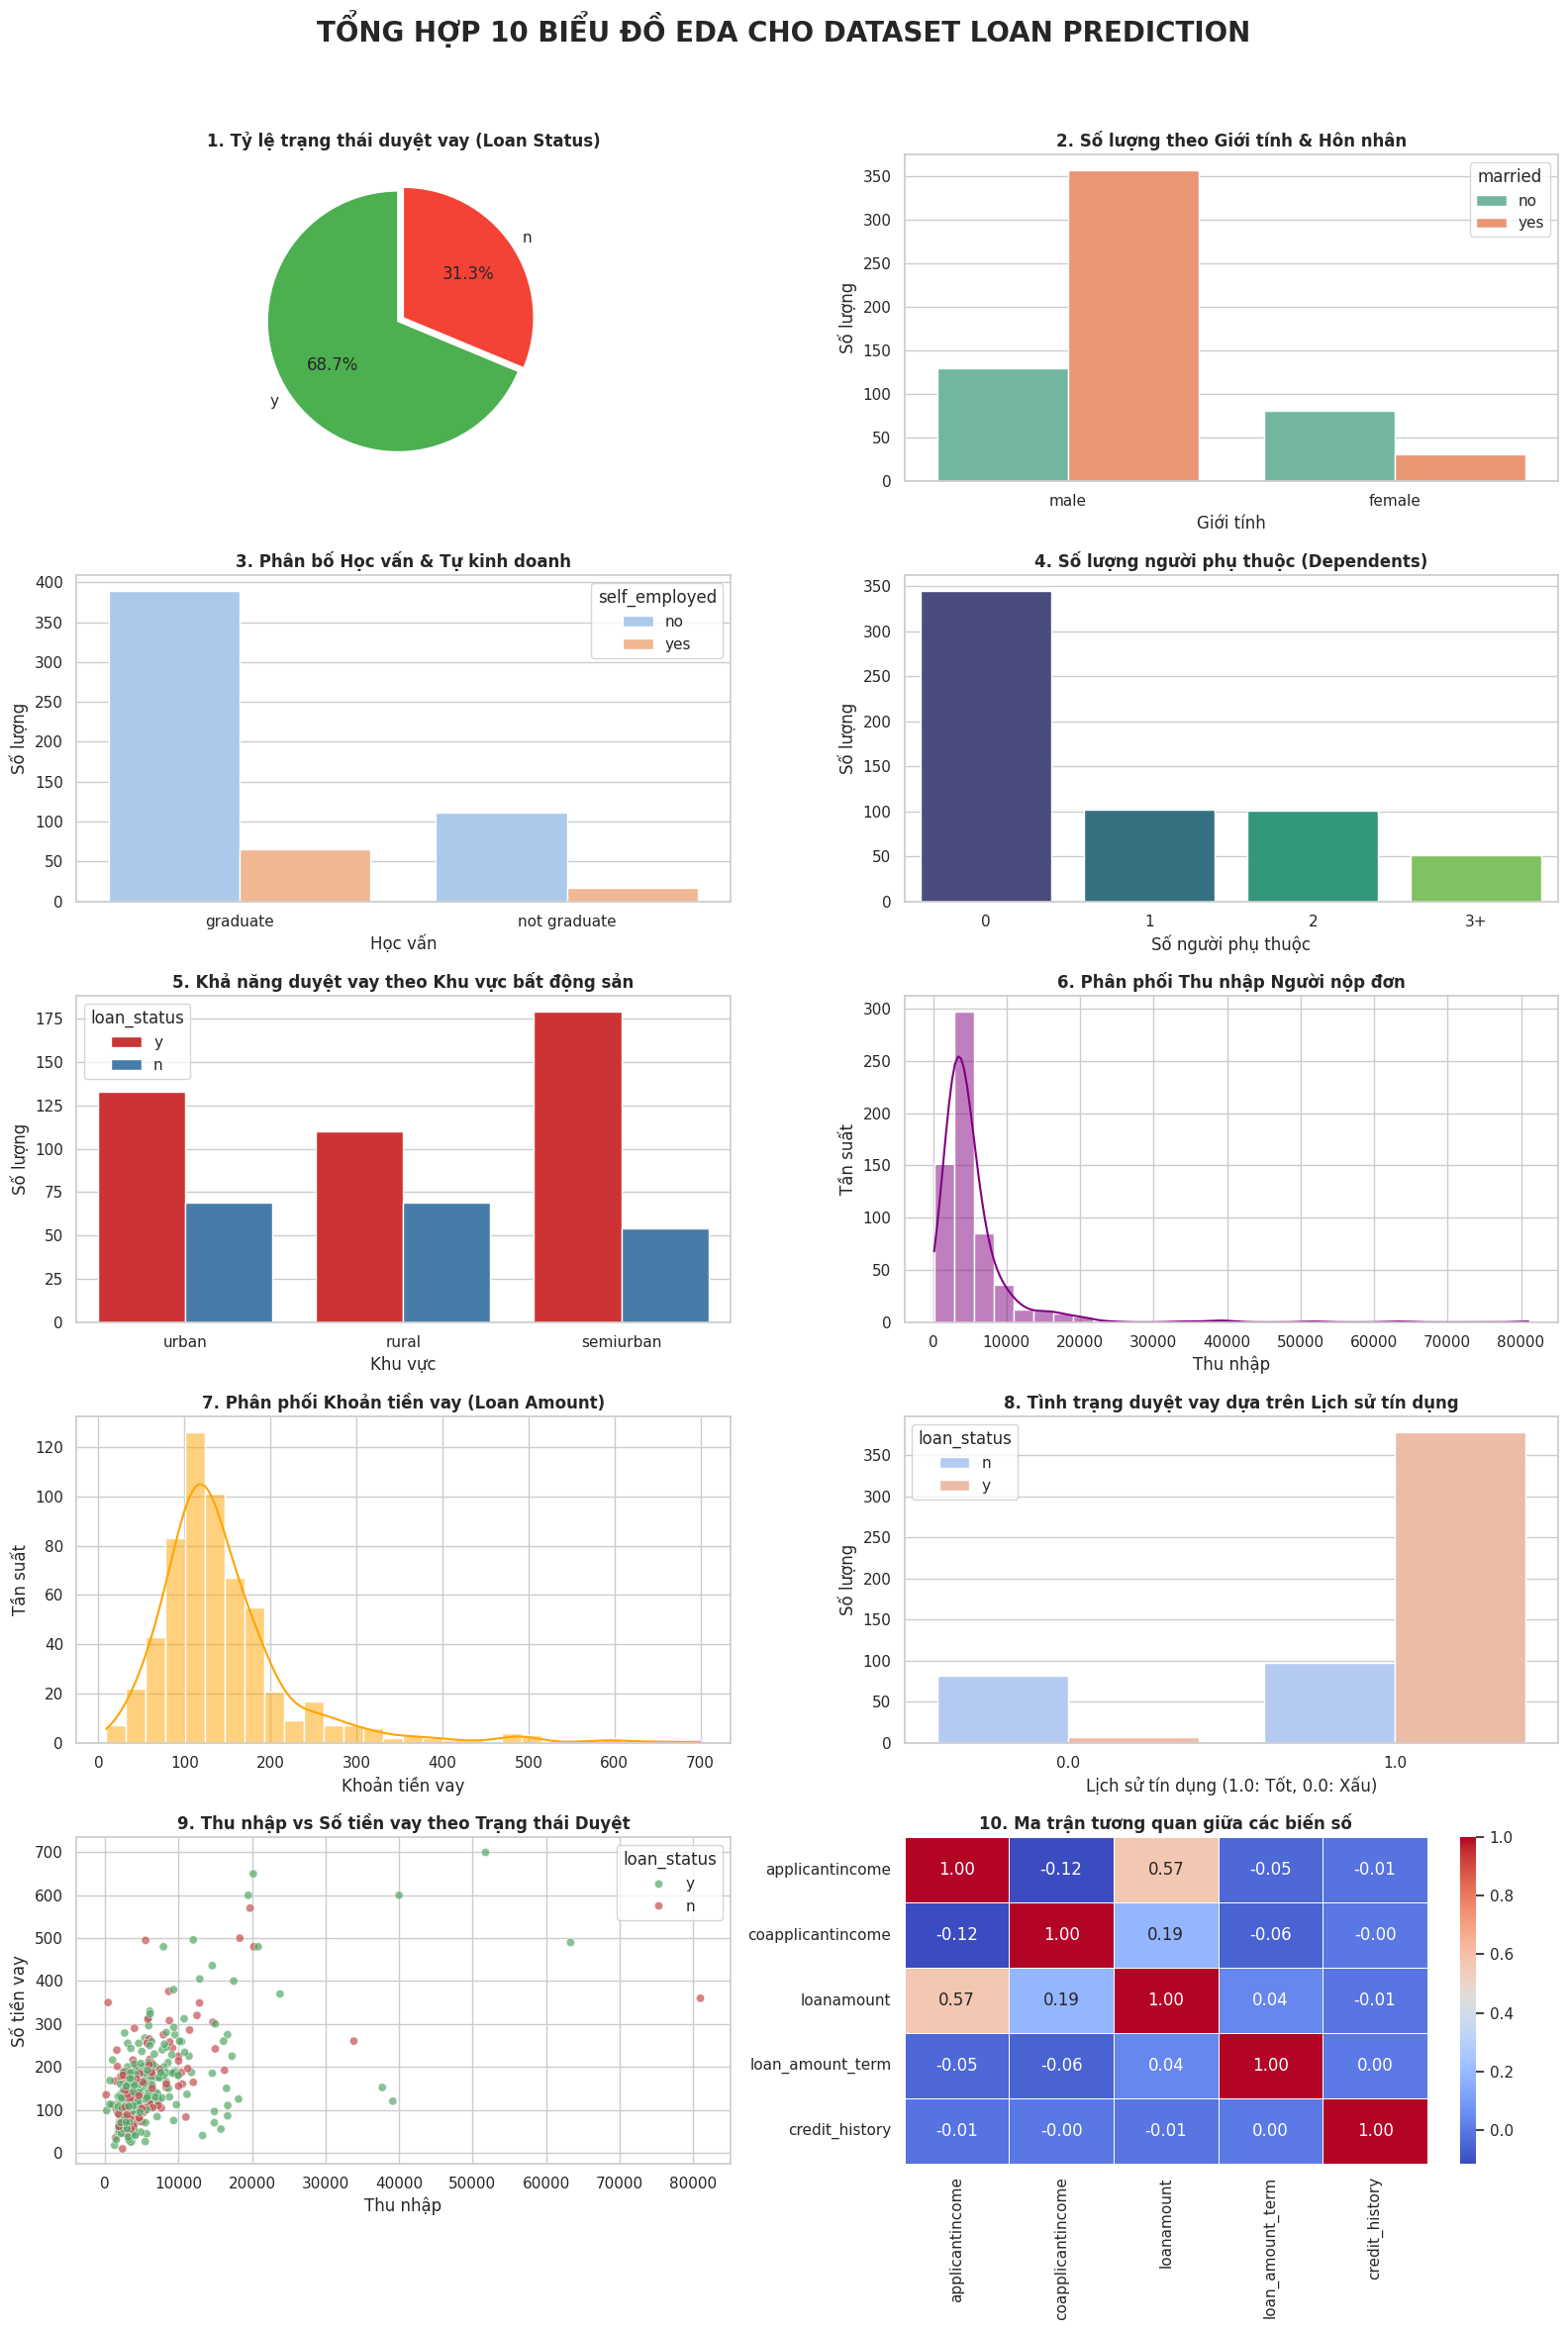

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập giao diện và cỡ chữ chung cho các biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
fig.suptitle('TỔNG HỢP 10 BIỂU ĐỒ EDA CHO DATASET LOAN PREDICTION', fontsize=20, fontweight='bold', y=0.98)

# 1. Biểu đồ tròn: Tỷ lệ duyệt hồ sơ (Target Variable)
ax1 = axes[0, 0]
df['loan_status'].value_index = df['loan_status'].value_counts()
ax1.pie(df['loan_status'].value_counts(), labels=df['loan_status'].value_counts().index, autopct='%1.1f%%',
        startangle=90, colors=['#4CAF50', '#F44336'], explode=(0.05, 0))
ax1.set_title("1. Tỷ lệ trạng thái duyệt vay (Loan Status)", fontsize=12, fontweight='bold')

# 2. Biểu đồ cột: Giới tính & Tình trạng hôn nhân
ax2 = axes[0, 1]
sns.countplot(data=df, x='gender', hue='married', ax=ax2, palette='Set2')
ax2.set_title("2. Số lượng theo Giới tính & Hôn nhân", fontsize=12, fontweight='bold')
ax2.set_xlabel("Giới tính")
ax2.set_ylabel("Số lượng")

# 3. Biểu đồ cột: Học vấn & Tự kinh doanh
ax3 = axes[1, 0]
sns.countplot(data=df, x='education', hue='self_employed', ax=ax3, palette='pastel')
ax3.set_title("3. Phân bố Học vấn & Tự kinh doanh", fontsize=12, fontweight='bold')
ax3.set_xlabel("Học vấn")
ax3.set_ylabel("Số lượng")

# 4. Biểu đồ cột: Số lượng người phụ thuộc
ax4 = axes[1, 1]
sns.countplot(data=df, x='dependents', ax=ax4, order=['0', '1', '2', '3+'], palette='viridis')
ax4.set_title("4. Số lượng người phụ thuộc (Dependents)", fontsize=12, fontweight='bold')
ax4.set_xlabel("Số người phụ thuộc")
ax4.set_ylabel("Số lượng")

# 5. Biểu đồ cột thể hiện khu vực bất động sản
ax5 = axes[2, 0]
sns.countplot(data=df, x='property_area', hue='loan_status', ax=ax5, palette='Set1')
ax5.set_title("5. Khả năng duyệt vay theo Khu vực bất động sản", fontsize=12, fontweight='bold')
ax5.set_xlabel("Khu vực")
ax5.set_ylabel("Số lượng")

# 6. Biểu đồ phân phối: Thu nhập của Người nộp đơn (Applicant Income)
ax6 = axes[2, 1]
sns.histplot(data=df, x='applicantincome', kde=True, ax=ax6, color='purple', bins=30)
ax6.set_title("6. Phân phối Thu nhập Người nộp đơn", fontsize=12, fontweight='bold')
ax6.set_xlabel("Thu nhập")
ax6.set_ylabel("Tần suất")

# 7. Biểu đồ phân phối: Số tiền vay (Loan Amount)
ax7 = axes[3, 0]
sns.histplot(data=df, x='loanamount', kde=True, ax=ax7, color='orange', bins=30)
ax7.set_title("7. Phân phối Khoản tiền vay (Loan Amount)", fontsize=12, fontweight='bold')
ax7.set_xlabel("Khoản tiền vay")
ax7.set_ylabel("Tần suất")

# 8. Mối liên hệ giữa Lịch sử tín dụng và Trạng thái duyệt vay
ax8 = axes[3, 1]
sns.countplot(data=df, x='credit_history', hue='loan_status', ax=ax8, palette='coolwarm')
ax8.set_title("8. Tình trạng duyệt vay dựa trên Lịch sử tín dụng", fontsize=12, fontweight='bold')
ax8.set_xlabel("Lịch sử tín dụng (1.0: Tốt, 0.0: Xấu)")
ax8.set_ylabel("Số lượng")

# 9. Biểu đồ phân tán: Thu nhập vs Khoản vay theo Trạng thái duyệt
ax9 = axes[4, 0]
sns.scatterplot(data=df, x='applicantincome', y='loanamount', hue='loan_status', alpha=0.7, ax=ax9, palette=['g', 'r'])
ax9.set_title("9. Thu nhập vs Số tiền vay theo Trạng thái Duyệt", fontsize=12, fontweight='bold')
ax9.set_xlabel("Thu nhập")
ax9.set_ylabel("Số tiền vay")

# 10. Bản đồ nhiệt tương quan (Correlation Heatmap) cho các biến số
ax10 = axes[4, 1]
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax10)
ax10.set_title("10. Ma trận tương quan giữa các biến số", fontsize=12, fontweight='bold')

# Tối ưu hóa khoảng cách giữa các biểu đồ
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()